In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from behavior_utils import *

In [6]:
base_path    = "s:/"
experiment   = "clickbait-motivate"
trial_count_paths = get_file_paths(f"{base_path}/{experiment}/", 'txt', 'trialcounts', session_type='', print_paths=True, print_n=3)

Found 47 trialcounts.txt files
0 s:\clickbait-motivate\bonsai\7010\m1\10082025_7010_m1_trialcounts.txt
1 s:\clickbait-motivate\bonsai\7010\m2\10092025_7010_m2_trialcounts.txt
2 s:\clickbait-motivate\bonsai\7010\m4\10132025_7010_m4_trialcounts.txt


In [18]:
mouse_ids = []
session_ids = []
trial_counts = []

# Get trial counts for each session using regular expressions
# Get digits after "Total: "
for trial_path in trial_count_paths:
    with open(trial_path, 'r') as f:
        content = f.read()
        match = re.search(r'Total:\s*(\d+)', content)
        if match:
            total_trials = int(match.group(1))
            trial_counts.append(total_trials)
            mouse_ids.append(trial_path.parts[-3])  # Assuming mouse ID is the third last part of the path
            session_ids.append(trial_path.parts[-2][1:])  # Assuming session ID is the second to last part of the path, and there is a prefix character to remove

In [19]:
# Create a DataFrame to store the trial counts
trial_counts_df = pd.DataFrame({
    'mouse_id': mouse_ids,
    'session_id': session_ids,
    'trials_completed': trial_counts
})


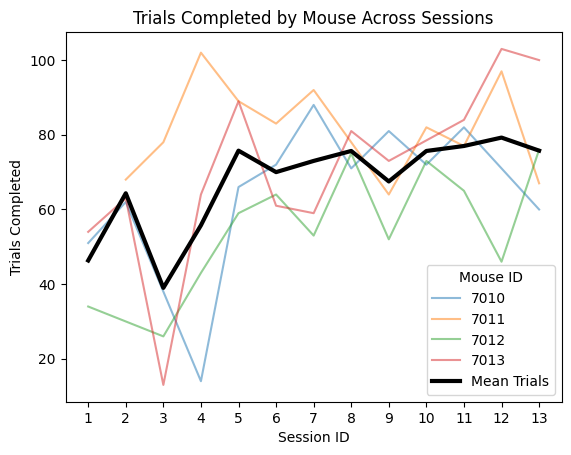

In [61]:
# Plotting trials completed by mouse across sessions
for mouse_id, group in trial_counts_df.groupby('mouse_id'):
    group['session_id'] = group['session_id'].astype(int)  # Convert session_id to int
    group_sorted = group.sort_values('session_id')  # Sort by session_id
    plt.plot(group_sorted['session_id']-1, group_sorted['trials_completed'], marker='', label=mouse_id, alpha=0.5)

# Calculate and plot the mean line using sorted session_ids
mean_trials = trial_counts_df.groupby('session_id')['trials_completed'].mean()
mean_trials = mean_trials.sort_index(key=lambda x: x.astype(int))
plt.plot(mean_trials.index, mean_trials, color='black', label='Mean Trials', linewidth=3)  # Use index directly

plt.title('Trials Completed by Mouse Across Sessions')
plt.xlabel('Session ID')
plt.ylabel('Trials Completed')
plt.legend(title='Mouse ID')
plt.show()
